# Module 3 — Probability Distributions

**Statistics Deep Dive · Notebook 3 of 13**

A probability distribution is a **model of how data is generated**. A surprisingly small zoo of named distributions covers most real-world situations — because each one is the mathematical consequence of a simple *story* ("count successes in n tries", "wait for the next random event", "add up many small effects"). Learn the stories and you will recognise the distributions in the wild.

### 🎯 Learning goals
1. Move fluently between **PMF/PDF, CDF, survival function and quantile function (PPF)** — and their `scipy.stats` methods.
2. Know the *story*, parameters, mean and variance of the key **discrete** distributions (Bernoulli, binomial, geometric, Poisson) …
3. … and the key **continuous** ones (uniform, normal, exponential, gamma, beta, lognormal).
4. Understand where the **sampling distributions** $t$, $\chi^2$ and $F$ come from.
5. Read **Q–Q plots** and **fit** distributions to data by maximum likelihood.

### 🗺️ Contents
1. Four functions that describe a distribution · 2. Discrete distributions · 3. The Poisson process · 4. Continuous distributions · 5. $t$, $\chi^2$, $F$ · 6. Summary table · 7. Q–Q plots · 8. Fitting distributions · 9. Interactive explorer · 10. Exercises · 11. Takeaways

In [1]:
# --- Course setup (identical in every module) ---
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (9, 4.2), "figure.dpi": 90, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False})
C = sns.color_palette("deep")      # C[0] blue, C[1] orange, C[2] green, C[3] red, C[4] purple
rng = np.random.default_rng(42)    # seeded generator => reproducible results

---
## 1. Four functions that describe a distribution

| Function | Question it answers | Discrete | Continuous | `scipy.stats` |
|---|---|---|---|---|
| **PMF / PDF** | how likely / how dense is the value $x$? | $p(x) = P(X = x)$ | $f(x)$ — a *density*: only **areas** are probabilities, $P(a<X\le b)=\int_a^b f$ | `.pmf(x)` / `.pdf(x)` |
| **CDF** | probability of *at most* $x$? | $F(x) = P(X \le x)$ | same | `.cdf(x)` |
| **Survival function** | probability of *more than* $x$? | $S(x) = 1 - F(x)$ | same | `.sf(x)` (more accurate than `1 - cdf` in the far tail) |
| **Quantile function (PPF)** | which value has probability $q$ below it? | $F^{-1}(q)$ | same | `.ppf(q)` |

Also: `.rvs(size)` draws random numbers, `.mean()`, `.std()`, `.interval(0.95)`, and `.fit(data)` estimates parameters.

> ⚠️ For a continuous variable $P(X = x) = 0$ for every single $x$, and a density can exceed 1 (e.g. a uniform on $[0, 0.1]$ has $f = 10$). Only areas matter.

The figure shows how the functions are linked, using IQ scores ($\mu = 100$, $\sigma = 15$).

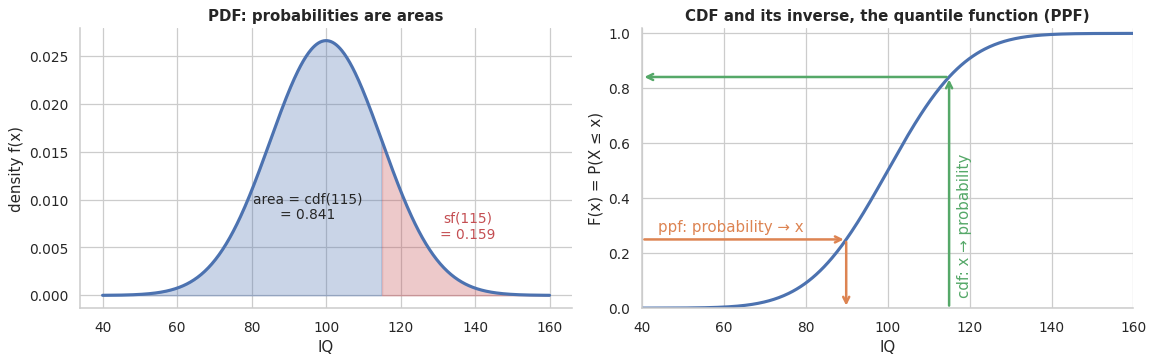

P(IQ ≤ 115) = 0.8413 | P(IQ > 130) = 0.0228 | P(85 < IQ ≤ 115) = 0.6827 | top-1 % threshold = 134.9


In [2]:
d = stats.norm(100, 15); x = np.linspace(40, 160, 500); x0 = 115; q = d.cdf(x0)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.2))
a1.plot(x, d.pdf(x), color=C[0], lw=2.5); a1.fill_between(x[x <= x0], d.pdf(x[x <= x0]), color=C[0], alpha=.3)
a1.fill_between(x[x >= x0], d.pdf(x[x >= x0]), color=C[3], alpha=.3)
a1.text(95, .008, f"area = cdf({x0})\n= {q:.3f}", ha="center", fontsize=11); a1.text(138, .006, f"sf({x0})\n= {1 - q:.3f}", ha="center", color=C[3], fontsize=11)
a1.set(title="PDF: probabilities are areas", xlabel="IQ", ylabel="density f(x)")
a2.plot(x, d.cdf(x), color=C[0], lw=2.5)
a2.annotate("", xy=(x0, q), xytext=(x0, 0), arrowprops=dict(arrowstyle="->", color=C[2], lw=2)); a2.annotate("", xy=(40, q), xytext=(x0, q), arrowprops=dict(arrowstyle="->", color=C[2], lw=2))
a2.text(x0 + 2, .3, "cdf: x → probability", color=C[2], rotation=90, va="center")
q2 = .25; a2.annotate("", xy=(d.ppf(q2), q2), xytext=(40, q2), arrowprops=dict(arrowstyle="->", color=C[1], lw=2)); a2.annotate("", xy=(d.ppf(q2), 0), xytext=(d.ppf(q2), q2), arrowprops=dict(arrowstyle="->", color=C[1], lw=2))
a2.text(44, q2 + .03, "ppf: probability → x", color=C[1])
a2.set(title="CDF and its inverse, the quantile function (PPF)", xlabel="IQ", ylabel="F(x) = P(X ≤ x)", xlim=(40, 160), ylim=(0, 1.02))
plt.tight_layout(); plt.show()
print(f"P(IQ ≤ 115) = {d.cdf(115):.4f} | P(IQ > 130) = {d.sf(130):.4f} | P(85 < IQ ≤ 115) = {d.cdf(115) - d.cdf(85):.4f} | top-1 % threshold = {d.ppf(.99):.1f}")

---
## 2. Discrete distributions — counting things

### 2.1 Bernoulli and binomial: "how many successes in $n$ independent tries?"

* **Bernoulli($p$)**: one yes/no trial, $P(X=1)=p$. Mean $p$, variance $p(1-p)$ (largest at $p=0.5$).
* **Binomial($n, p$)**: number of successes in $n$ *independent* trials with *constant* $p$:

$$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}, \qquad \mathbb{E}[X] = np, \qquad \operatorname{Var}(X) = np(1-p)$$

*In the wild:* defective items in a batch, conversions among $n$ visitors, patients responding to a drug, votes for a party in a poll.

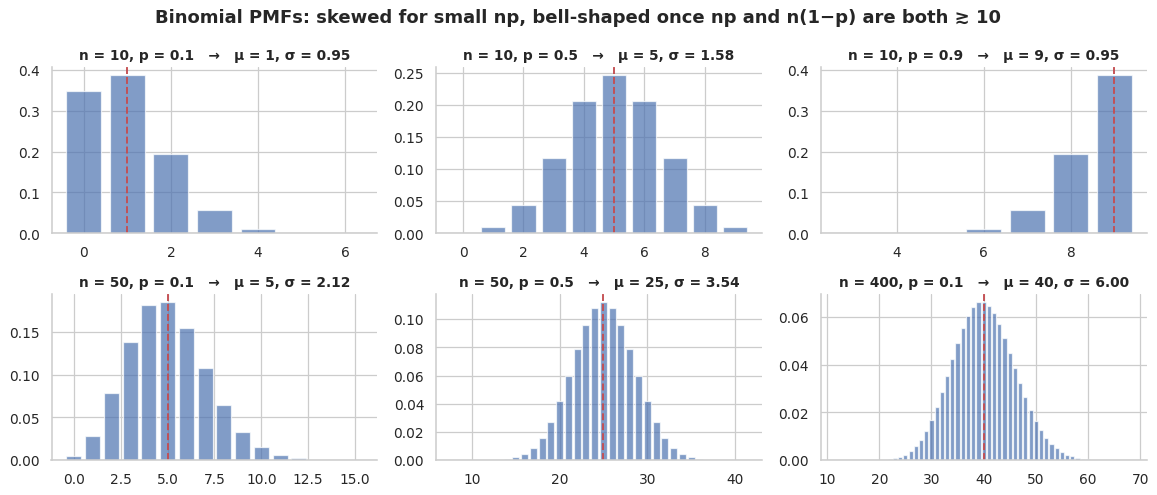

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(13, 5.6))
for ax, (n, p) in zip(axes.ravel(), [(10, .1), (10, .5), (10, .9), (50, .1), (50, .5), (400, .1)]):
    mu, sd = n * p, np.sqrt(n * p * (1 - p)); k = np.arange(max(0, int(mu - 4.5 * sd) - 1), min(n, int(mu + 4.5 * sd) + 2))
    ax.bar(k, stats.binom.pmf(k, n, p), color=C[0], alpha=.7); ax.axvline(mu, color=C[3], ls="--")
    ax.set_title(f"n = {n}, p = {p}   →   μ = {mu:g}, σ = {sd:.2f}", fontsize=11)
fig.suptitle("Binomial PMFs: skewed for small np, bell-shaped once np and n(1−p) are both ≳ 10", fontweight="bold"); plt.tight_layout(); plt.show()

### 2.2 Geometric: "how many tries until the first success?"
$P(X=k) = (1-p)^{k-1}p$, mean $1/p$. *In the wild:* number of sales calls until the first deal, attempts until a flaky test passes. It is the only **memoryless** discrete distribution — having failed 10 times does not make success "due".

### 2.3 Poisson: "how many events in a fixed interval?"
If events occur **independently** at a **constant average rate**, the count in an interval with expected number $\lambda$ is

$$P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}, \qquad \mathbb{E}[X] = \operatorname{Var}(X) = \lambda$$

*In the wild:* calls per hour, typos per page, goals per football match, radioactive decays per second, claims per policy-year. The identity **mean = variance** is a quick diagnostic; real count data is often *overdispersed* (variance > mean → negative binomial, Module 11).

The Poisson is the limit of the binomial for **many trials with a small success probability** ($n\to\infty$, $p\to0$, $np=\lambda$) — hence its old name "law of rare events".

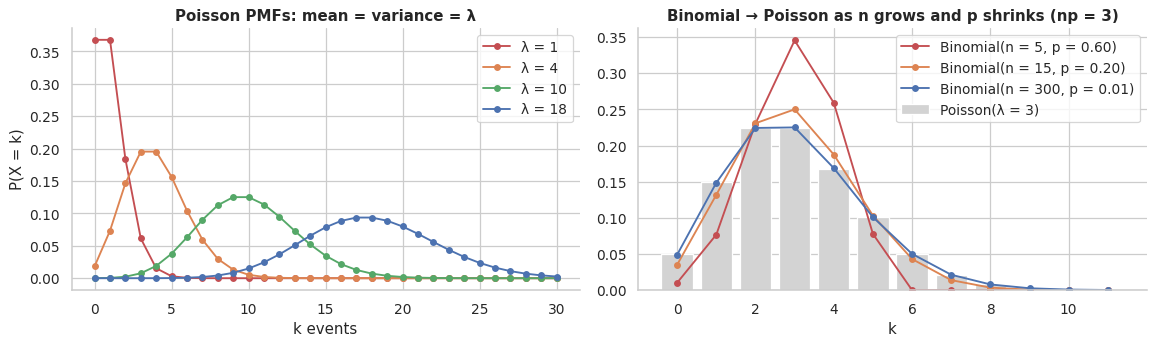

In [4]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
k = np.arange(0, 31)
for lam, col in zip([1, 4, 10, 18], [C[3], C[1], C[2], C[0]]):
    a1.plot(k, stats.poisson.pmf(k, lam), "o-", color=col, ms=4.5, label=f"λ = {lam}")
a1.set(title="Poisson PMFs: mean = variance = λ", xlabel="k events", ylabel="P(X = k)"); a1.legend()

k = np.arange(0, 12); a2.bar(k, stats.poisson.pmf(k, 3), color="lightgrey", label="Poisson(λ = 3)")
for n, col in zip([5, 15, 300], [C[3], C[1], C[0]]):
    a2.plot(k, stats.binom.pmf(k, n, 3 / n), "o-", ms=4.5, color=col, label=f"Binomial(n = {n}, p = {3 / n:.2f})")
a2.set(title="Binomial → Poisson as n grows and p shrinks (np = 3)", xlabel="k"); a2.legend(); plt.tight_layout(); plt.show()

---
## 3. The Poisson process — one story, three distributions

Imagine customers arriving completely at random at a rate of $\lambda = 4$ per hour. This single mechanism generates:

* the **number of arrivals per hour** → Poisson($\lambda$),
* the **waiting time between two arrivals** → Exponential with mean $1/\lambda$,
* the **waiting time until the $k$-th arrival** → Gamma($k$, $1/\lambda$).

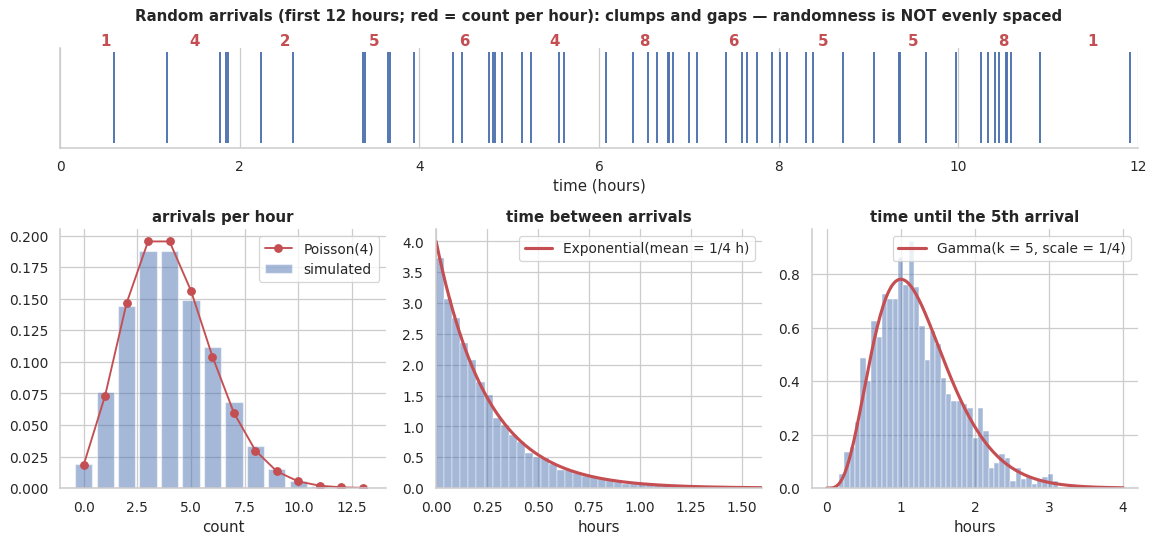

In [5]:
lam, T = 4, 2000                                                   # rate per hour, hours simulated
gaps = rng.exponential(1 / lam, int(lam * T * 1.2)); arrivals = gaps.cumsum(); arrivals = arrivals[arrivals < T]
counts = np.bincount(arrivals.astype(int), minlength=T)

fig = plt.figure(figsize=(13, 6.2)); gs = fig.add_gridspec(2, 3, height_ratios=[1, 2.6])
a0 = fig.add_subplot(gs[0, :]); a0.vlines(arrivals[arrivals < 12], 0, 1, color=C[0]); a0.set(xlim=(0, 12), yticks=[], xlabel="time (hours)"); a0.set_title("Random arrivals (first 12 hours; red = count per hour): clumps and gaps — randomness is NOT evenly spaced", pad=22)
for h in range(12): a0.text(h + .5, 1.08, str(counts[h]), ha="center", color=C[3], fontweight="bold")
a1 = fig.add_subplot(gs[1, 0]); kk = np.arange(0, 14)
a1.bar(kk, np.bincount(counts, minlength=14)[:14] / T, color=C[0], alpha=.5, label="simulated"); a1.plot(kk, stats.poisson.pmf(kk, lam), "o-", color=C[3], label="Poisson(4)")
a1.set(title="arrivals per hour", xlabel="count"); a1.legend()
a2 = fig.add_subplot(gs[1, 1]); xx = np.linspace(0, 1.6, 200)
sns.histplot(np.diff(arrivals), bins=60, stat="density", ax=a2, color=C[0], alpha=.5); a2.plot(xx, stats.expon.pdf(xx, scale=1 / lam), color=C[3], lw=2.5, label="Exponential(mean = 1/4 h)")
a2.set(title="time between arrivals", xlabel="hours", xlim=(0, 1.6), ylabel=""); a2.legend()
a3 = fig.add_subplot(gs[1, 2]); w5 = arrivals[4::5] - np.concatenate([[0], arrivals[4::5][:-1]]); xx = np.linspace(0, 4, 200)
sns.histplot(w5, bins=50, stat="density", ax=a3, color=C[0], alpha=.5); a3.plot(xx, stats.gamma.pdf(xx, a=5, scale=1 / lam), color=C[3], lw=2.5, label="Gamma(k = 5, scale = 1/4)")
a3.set(title="time until the 5th arrival", xlabel="hours", ylabel=""); a3.legend(); plt.tight_layout(); plt.show()

---
## 4. Continuous distributions — measuring things

### 4.1 The normal (Gaussian) distribution
$$f(x) = \frac{1}{\sigma\sqrt{2\pi}}\exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

**Story:** the *sum of many small independent effects* is approximately normal (central limit theorem, Module 4). That is why measurement errors, body heights and sample means are bell-shaped. $\mu$ shifts the curve, $\sigma$ stretches it.

**Standardisation:** $Z = (X-\mu)/\sigma$ is standard normal $N(0,1)$ — the **z-score** says "how many standard deviations from the mean". The **68–95–99.7 rule**:

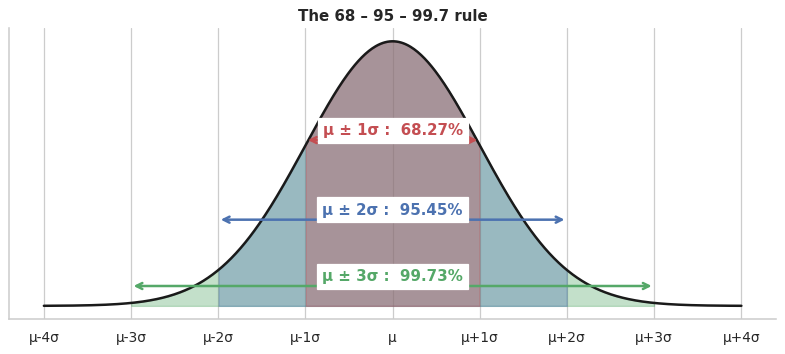

Beyond ±3σ: 1 in 370 | beyond ±4σ: 1 in 15,787 | beyond ±6σ: 1 in 506,797,346


In [6]:
z = np.linspace(-4, 4, 600); pdf = stats.norm.pdf(z)
fig, ax = plt.subplots(figsize=(11, 4.2)); ax.plot(z, pdf, color="k", lw=2)
for k, col, y in [(3, C[2], .03), (2, C[0], .13), (1, C[3], .25)]:
    m = np.abs(z) <= k; ax.fill_between(z[m], pdf[m], color=col, alpha=.35)
    ax.annotate("", xy=(-k, y), xytext=(k, y), arrowprops=dict(arrowstyle="<->", color=col, lw=2))
    ax.text(0, y + .008, f"μ ± {k}σ :  {stats.norm.cdf(k) - stats.norm.cdf(-k):.2%}", ha="center", color=col, fontweight="bold", backgroundcolor="w")
ax.set(xticks=range(-4, 5), xticklabels=[f"μ{k:+d}σ" if k else "μ" for k in range(-4, 5)], yticks=[], title="The 68 – 95 – 99.7 rule"); plt.show()
print("Beyond ±3σ: 1 in", round(1 / (2 * stats.norm.sf(3))), "| beyond ±4σ: 1 in", f"{round(1 / (2 * stats.norm.sf(4))):,}", "| beyond ±6σ: 1 in", f"{round(1 / (2 * stats.norm.sf(6))):,}")

> ⚠️ **The normal has extremely thin tails.** A 6σ event "should" happen once in 500 million draws. If your data shows such events regularly (financial returns, network traffic, insurance losses), the normal model is *wrong in the tails* — exactly where risk lives.

### 4.2 Exponential — waiting for a random event, and the memoryless property
$f(t) = \lambda e^{-\lambda t}$, mean $1/\lambda$, standard deviation $1/\lambda$. **Memoryless:** $P(T > s + t \mid T > s) = P(T > t)$ — a component that has survived 5 years is "as good as new". Correct for random shocks (radioactive decay, arrivals), **wrong for wear-out** (bearings, humans), where the Weibull or gamma distribution is used.

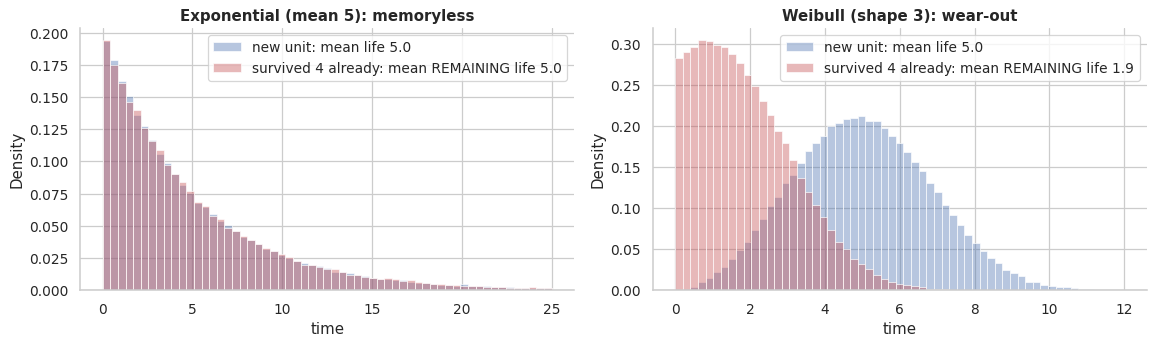

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)
samples = {"Exponential (mean 5): memoryless": rng.exponential(5, 200_000), "Weibull (shape 3): wear-out": 5.6 * rng.weibull(3, 200_000)}
for ax, (name, t) in zip(axes, samples.items()):
    rest = t[t > 4] - 4                                           # remaining life of the units that already survived 4 time units
    sns.histplot(t, bins=np.linspace(0, 25 if "Exp" in name else 12, 60), stat="density", ax=ax, color=C[0], alpha=.4, label=f"new unit: mean life {t.mean():.1f}")
    sns.histplot(rest, bins=np.linspace(0, 25 if "Exp" in name else 12, 60), stat="density", ax=ax, color=C[3], alpha=.4, label=f"survived 4 already: mean REMAINING life {rest.mean():.1f}")
    ax.set(title=name, xlabel="time"); ax.legend()
plt.tight_layout(); plt.show()

### 4.3 Gamma, beta and lognormal — three flexible shapes for positive or bounded data

| Distribution | Support | Story | In the wild |
|---|---|---|---|
| **Gamma**($k$, $\theta$) | $x>0$ | sum of $k$ exponential waiting times; flexible right-skewed shape | rainfall amounts, service times, claim sizes |
| **Beta**($a$, $b$) | $0<x<1$ | distribution of a *proportion / probability*; $a-1$ successes and $b-1$ failures observed | conversion rates, batting averages, Bayesian priors (Module 12) |
| **Lognormal**($\mu$, $\sigma$) | $x>0$ | **product** of many small independent factors ⇒ $\ln X$ is normal | incomes, stock prices, city sizes, latency, particle sizes |

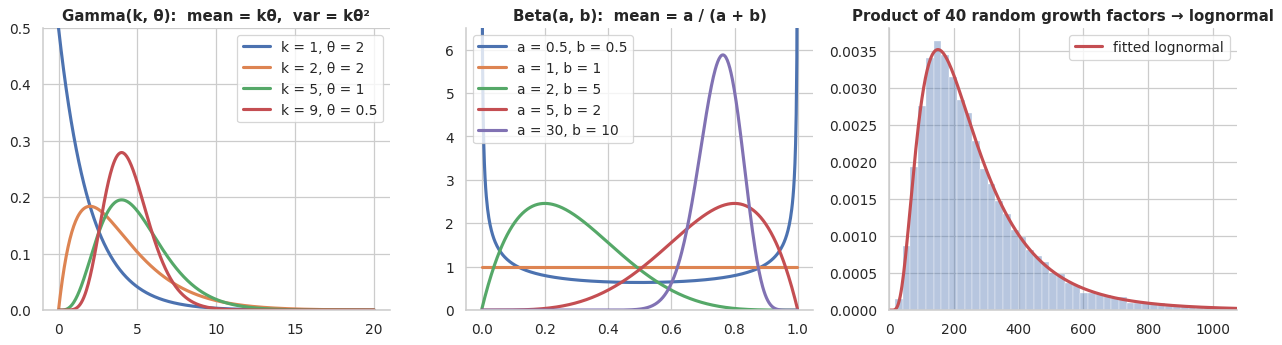

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
x = np.linspace(0.001, 20, 500)
for (k, th), col in zip([(1, 2), (2, 2), (5, 1), (9, .5)], C): axes[0].plot(x, stats.gamma.pdf(x, a=k, scale=th), lw=2.5, color=col, label=f"k = {k}, θ = {th}")
axes[0].set(title="Gamma(k, θ):  mean = kθ,  var = kθ²", ylim=(0, .5)); axes[0].legend()
x = np.linspace(0.001, .999, 500)
for (a, b), col in zip([(.5, .5), (1, 1), (2, 5), (5, 2), (30, 10)], C): axes[1].plot(x, stats.beta.pdf(x, a, b), lw=2.5, color=col, label=f"a = {a}, b = {b}")
axes[1].set(title="Beta(a, b):  mean = a / (a + b)", ylim=(0, 6.5)); axes[1].legend()
growth = 100 * rng.uniform(.85, 1.20, (20_000, 40)).prod(axis=1)             # 40 random multiplicative shocks
sns.histplot(growth, bins=80, stat="density", ax=axes[2], color=C[0], alpha=.4)
s, loc, scale = stats.lognorm.fit(growth, floc=0); xx = np.linspace(1, np.quantile(growth, .995), 400)
axes[2].plot(xx, stats.lognorm.pdf(xx, s, loc, scale), color=C[3], lw=2.5, label="fitted lognormal"); axes[2].set(xlim=(0, xx.max()), title="Product of 40 random growth factors → lognormal", ylabel=""); axes[2].legend()
plt.tight_layout(); plt.show()

---
## 5. The sampling distributions: $t$, $\chi^2$ and $F$

These three rarely describe raw data. They describe **statistics computed from normal samples** and are the reference distributions of classical tests (Modules 5–9).

| Distribution | Construction ($Z_i \sim N(0,1)$ independent) | Where you will meet it |
|---|---|---|
| **Chi-square** $\chi^2_k$ | $Z_1^2 + \dots + Z_k^2$ | sample variance, goodness-of-fit and independence tests |
| **Student's t** $t_k$ | $Z \big/ \sqrt{\chi^2_k / k}$ | the mean when $\sigma$ must be *estimated*: CIs, t-tests, regression coefficients |
| **F** $F_{k_1,k_2}$ | $\dfrac{\chi^2_{k_1}/k_1}{\chi^2_{k_2}/k_2}$ | ratio of two variances: ANOVA, comparing regression models |

The parameter $k$ is called **degrees of freedom** (df). As $k \to \infty$, $t_k \to N(0,1)$: with lots of data, estimating $\sigma$ costs nothing.

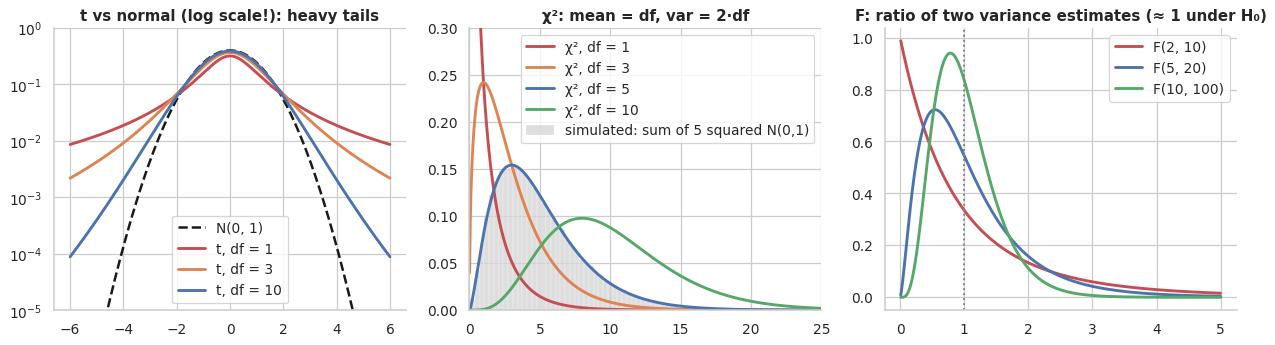

97.5 % quantiles:  normal 1.96 | t(30) 2.04 | t(10) 2.23 | t(3) 3.18   <- why small-sample intervals are wider


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
x = np.linspace(-6, 6, 500); axes[0].plot(x, stats.norm.pdf(x), "k--", lw=2, label="N(0, 1)")
for df, col in zip([1, 3, 10], [C[3], C[1], C[0]]): axes[0].plot(x, stats.t.pdf(x, df), color=col, lw=2.3, label=f"t, df = {df}")
axes[0].set(yscale="log", ylim=(1e-5, 1), title="t vs normal (log scale!): heavy tails"); axes[0].legend()
sim = (rng.normal(size=(100_000, 5)) ** 2).sum(axis=1); x = np.linspace(.01, 25, 500)
sns.histplot(sim, bins=100, stat="density", ax=axes[1], color="lightgrey", label="simulated: sum of 5 squared N(0,1)")
for df, col in zip([1, 3, 5, 10], [C[3], C[1], C[0], C[2]]): axes[1].plot(x, stats.chi2.pdf(x, df), color=col, lw=2.3, label=f"χ², df = {df}")
axes[1].set(xlim=(0, 25), ylim=(0, .3), title="χ²: mean = df, var = 2·df", ylabel=""); axes[1].legend()
x = np.linspace(.01, 5, 500)
for (d1, d2), col in zip([(2, 10), (5, 20), (10, 100)], [C[3], C[0], C[2]]): axes[2].plot(x, stats.f.pdf(x, d1, d2), color=col, lw=2.3, label=f"F({d1}, {d2})")
axes[2].axvline(1, color="grey", ls=":"); axes[2].set(title="F: ratio of two variance estimates (≈ 1 under H₀)"); axes[2].legend(); plt.tight_layout(); plt.show()
print(f"97.5 % quantiles:  normal {stats.norm.ppf(.975):.2f} | t(30) {stats.t.ppf(.975, 30):.2f} | t(10) {stats.t.ppf(.975, 10):.2f} | t(3) {stats.t.ppf(.975, 3):.2f}   <- why small-sample intervals are wider")

---
## 6. Summary table

| Distribution | `scipy.stats` | Support | Mean | Variance | One-line story |
|---|---|---|---|---|---|
| Bernoulli($p$) | `bernoulli(p)` | {0, 1} | $p$ | $p(1-p)$ | one yes/no trial |
| Binomial($n,p$) | `binom(n, p)` | 0…n | $np$ | $np(1-p)$ | successes in $n$ independent trials |
| Geometric($p$) | `geom(p)` | 1, 2, … | $1/p$ | $(1-p)/p^2$ | trials until first success |
| Neg. binomial($r,p$) | `nbinom(r, p)` | 0, 1, … | $r(1-p)/p$ | $r(1-p)/p^2$ | failures before the $r$-th success; overdispersed counts |
| Hypergeometric | `hypergeom(M, n, N)` | 0…N | $Nn/M$ | — | successes when sampling **without** replacement |
| Poisson($\lambda$) | `poisson(lam)` | 0, 1, … | $\lambda$ | $\lambda$ | events in a fixed interval at constant rate |
| Uniform($a,b$) | `uniform(a, b-a)` | $[a,b]$ | $\frac{a+b}{2}$ | $\frac{(b-a)^2}{12}$ | "know nothing but the range" |
| Normal($\mu,\sigma$) | `norm(mu, sigma)` | $\mathbb{R}$ | $\mu$ | $\sigma^2$ | sum of many small effects |
| Exponential($\lambda$) | `expon(scale=1/lam)` | $x>0$ | $1/\lambda$ | $1/\lambda^2$ | waiting time for a random event |
| Gamma($k,\theta$) | `gamma(k, scale=theta)` | $x>0$ | $k\theta$ | $k\theta^2$ | waiting time for the $k$-th event |
| Weibull($c,\eta$) | `weibull_min(c, scale=eta)` | $x>0$ | — | — | lifetimes with wear-out ($c>1$) or infant mortality ($c<1$) |
| Beta($a,b$) | `beta(a, b)` | $(0,1)$ | $\frac{a}{a+b}$ | $\frac{ab}{(a+b)^2(a+b+1)}$ | uncertainty about a probability |
| Lognormal($\mu,\sigma$) | `lognorm(s=sigma, scale=exp(mu))` | $x>0$ | $e^{\mu+\sigma^2/2}$ | — | product of many small factors |

> ⚠️ `scipy` parametrises everything with `loc` and `scale`. Always check the docs: `expon(scale=1/λ)`, `lognorm(s=σ, scale=e^μ)`, `uniform(loc=a, scale=b−a)`.

---
## 7. Q–Q plots — does my data follow this distribution?

A **quantile–quantile plot** plots the sorted data against the quantiles the model predicts. If the model fits, the points lie on a straight line. Deviations have characteristic shapes — far more informative than a histogram with an overlaid curve, and far more useful than a formal normality test (which rejects for trivial deviations when $n$ is large and cannot detect relevant ones when $n$ is small).

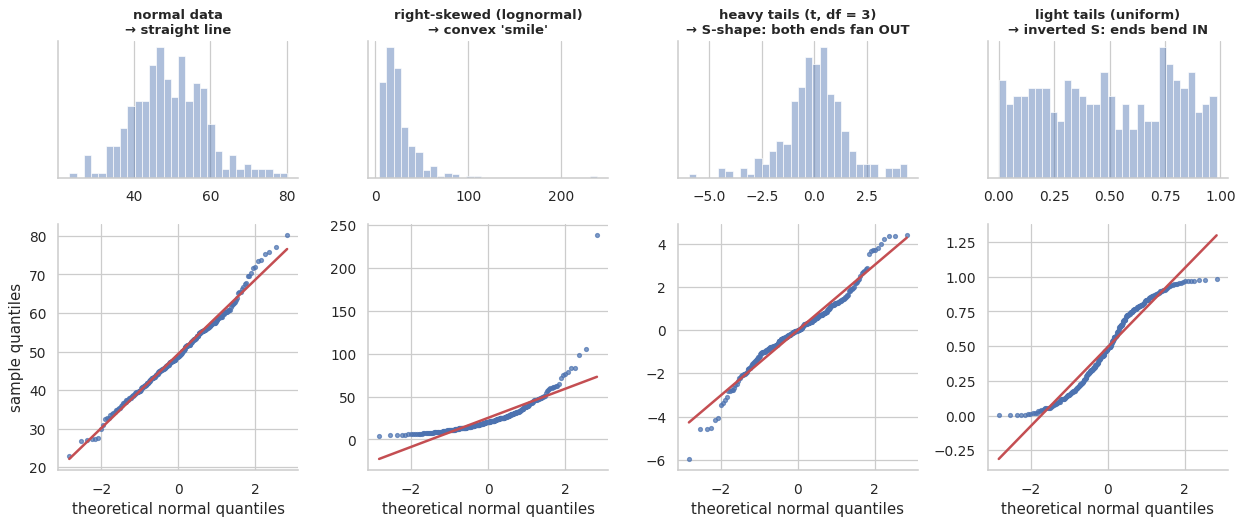

In [10]:
samples = {"normal data\n→ straight line": rng.normal(50, 10, 300),
           "right-skewed (lognormal)\n→ convex 'smile'": rng.lognormal(3, .6, 300),
           "heavy tails (t, df = 3)\n→ S-shape: both ends fan OUT": stats.t.rvs(3, size=300, random_state=rng),
           "light tails (uniform)\n→ inverted S: ends bend IN": rng.uniform(0, 1, 300)}
fig, axes = plt.subplots(2, 4, figsize=(14, 6), gridspec_kw={"height_ratios": [1, 1.8]})
for j, (name, s) in enumerate(samples.items()):
    sns.histplot(s, bins=30, ax=axes[0, j], color=C[0], alpha=.45); axes[0, j].set(ylabel="", yticks=[]); axes[0, j].set_title(name, fontsize=10.5)
    (osm, osr), (slope, inter, r) = stats.probplot(s, dist="norm")
    axes[1, j].scatter(osm, osr, s=10, color=C[0], alpha=.7); axes[1, j].plot(osm, inter + slope * osm, color=C[3], lw=2)
    axes[1, j].set(xlabel="theoretical normal quantiles", ylabel="sample quantiles" if j == 0 else "")
plt.tight_layout(); plt.show()

---
## 8. Fitting distributions to data (maximum likelihood) — worked example on real data

`dist.fit(data)` returns **maximum-likelihood estimates** (the parameter values under which the observed data is most probable; theory in Module 5). To compare candidate models use

$$\text{AIC} = 2k - 2\ln\hat L \qquad (k = \text{number of parameters; smaller is better})$$

together with Q–Q plots. *Data:* the mean cell-nucleus **area** of the 569 tumours in the Wisconsin breast-cancer data. Sizes of biological objects often arise from multiplicative growth, so we expect right skew.

,log-likelihood,AIC
model,,
normal,-4143.1,8290.3
gamma,-4036.3,8076.6
lognormal,-4013.6,8031.2


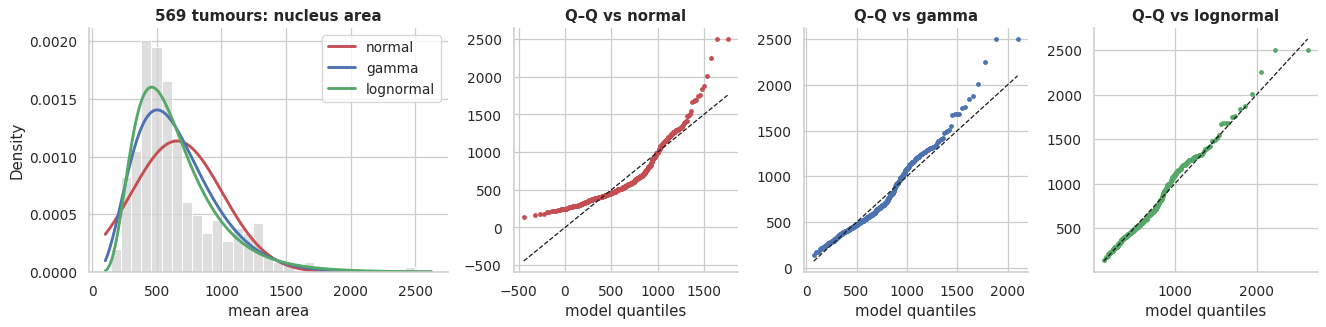

In [11]:
from sklearn.datasets import load_breast_cancer
bc = load_breast_cancer(as_frame=True); area = bc.frame["mean area"].to_numpy()

models = {"normal": (stats.norm, {}), "gamma": (stats.gamma, {"floc": 0}), "lognormal": (stats.lognorm, {"floc": 0})}
fits, rows = {}, []
for name, (dist, kw) in models.items():
    params = dist.fit(area, **kw); fits[name] = dist(*params)
    ll = fits[name].logpdf(area).sum(); rows.append({"model": name, "log-likelihood": ll, "AIC": 2 * 2 - 2 * ll})    # each model has 2 free parameters
display(pd.DataFrame(rows).set_index("model").round(1))

fig, axes = plt.subplots(1, 4, figsize=(15, 3.8), gridspec_kw={"width_ratios": [1.6, 1, 1, 1]})
sns.histplot(area, bins=30, stat="density", ax=axes[0], color="lightgrey"); xx = np.linspace(area.min() * .7, area.max() * 1.05, 400)
for (name, f), col in zip(fits.items(), [C[3], C[0], C[2]]):
    axes[0].plot(xx, f.pdf(xx), lw=2.3, color=col, label=name)
axes[0].set(title="569 tumours: nucleus area", xlabel="mean area"); axes[0].legend()
probs = (np.arange(1, len(area) + 1) - .5) / len(area)
for ax, (name, f), col in zip(axes[1:], fits.items(), [C[3], C[0], C[2]]):
    theo = f.ppf(probs); ax.scatter(theo, np.sort(area), s=8, color=col); ax.plot(theo, theo, "k--", lw=1)
    ax.set(title=f"Q–Q vs {name}", xlabel="model quantiles")
plt.tight_layout(); plt.show()

**Reading the results.** The normal model is clearly worst: its AIC is more than 200 points higher, it puts visible probability on impossible (negative or tiny) areas, and its Q–Q plot bends away at both ends. Gamma and lognormal both capture the right skew; AIC and Q–Q plot favour the **lognormal** — consistent with the multiplicative-growth story. Even the lognormal Q–Q plot shows a gentle wave around the middle: the data is really a *mixture* of two populations (benign and malignant tumours), something no single textbook distribution captures perfectly. *All models are wrong, some are useful.*

---
## 9. 🎛️ Interactive explorer — when do the normal and Poisson approximations of the binomial work?

If `ipywidgets` is installed you get sliders; otherwise a static example is drawn. Try: $n=20, p=0.5$ (normal ✓) · $n=500, p=0.01$ (Poisson ✓, normal ✗) · $n=20, p=0.05$ (nothing works well — use the exact binomial).

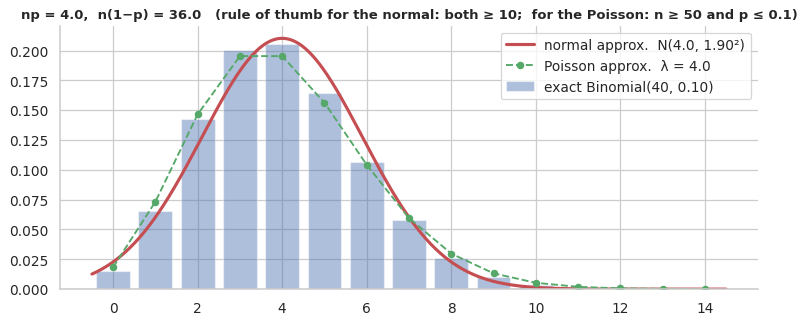

In [12]:
def explore_binomial(n=40, p=0.10):
    mu, sd = n * p, np.sqrt(n * p * (1 - p)); k = np.arange(max(0, int(mu - 5 * sd)), min(n, int(mu + 5 * sd) + 1) + 1)
    fig, ax = plt.subplots(figsize=(10, 3.8))
    ax.bar(k, stats.binom.pmf(k, n, p), color=C[0], alpha=.45, label=f"exact Binomial({n}, {p:.2f})")
    xx = np.linspace(k.min() - .5, k.max() + .5, 400); ax.plot(xx, stats.norm.pdf(xx, mu, sd), color=C[3], lw=2.5, label=f"normal approx.  N({mu:.1f}, {sd:.2f}²)")
    ax.plot(k, stats.poisson.pmf(k, mu), "o--", color=C[2], ms=5, label=f"Poisson approx.  λ = {mu:.1f}")
    ax.set_title(f"np = {mu:.1f},  n(1−p) = {n * (1 - p):.1f}   (rule of thumb for the normal: both ≥ 10;  for the Poisson: n ≥ 50 and p ≤ 0.1)", fontsize=10.5)
    ax.legend(); plt.show()

try:
    from ipywidgets import interact
    interact(explore_binomial, n=(5, 1000, 5), p=(0.01, 0.99, 0.01))
except ImportError:
    explore_binomial()

---
## 10. Exercises — real-world use cases

### ✍️ Exercise 3.1 — *Binomial*: Design an acceptance-sampling plan (Incoming goods inspection)

Your company buys resistors in lots of 10,000. Testing every part is too expensive, so QA inspects a random sample of $n$ parts and **accepts the lot if at most $c$ are defective**. Current plan: $n = 80$, $c = 2$.

**Tasks**
1. What is the probability of accepting a lot with a true defect rate of 1 % (a *good* lot)? Of 5 % (a *bad* lot)?
2. Plot the **operating-characteristic (OC) curve**: P(accept) as a function of the true defect rate from 0 to 12 %.
3. The contract demands: good lots (1 %) are accepted with probability ≥ 95 % (*producer's risk* ≤ 5 %), bad lots (5 %) with probability ≤ 10 % (*consumer's risk*). Does the current plan comply? Find the plan with the **smallest $n$** that does.
4. Why is the binomial only an approximation here, and why is it a good one?

In [13]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/03_probability_distributions_solutions.ipynb`.

### ✍️ Exercise 3.2 — *Poisson*: Staffing a call centre (Operations)

A support hotline logged the number of incoming calls for 500 peak hours (`calls`). One agent can handle 6 calls per hour.

**Tasks**
1. Estimate $\lambda$. Check the Poisson assumption: compare mean and variance, and overlay the Poisson PMF on the empirical distribution.
2. What is the probability of more than 24 calls in an hour (the capacity of 4 agents)?
3. Management wants the probability that calls exceed capacity to be **at most 5 %**. How many agents are needed?
4. What is the probability that **no call arrives for 10 minutes** (so an agent can take a short break)? Which distribution do you need?

In [14]:
g = np.random.default_rng(302)
calls = pd.Series(g.poisson(18.3, 500), name="calls_per_hour")
calls.describe().round(2)

count    500.00
mean      18.31
std        4.30
min        8.00
25%       15.00
50%       18.00
75%       21.00
max       31.00
Name: calls_per_hour, dtype: float64

In [15]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/03_probability_distributions_solutions.ipynb`.

### ✍️ Exercise 3.3 — *Normal*: How many shafts are out of tolerance? (Manufacturing / Six Sigma)

A lathe produces shafts with specified diameter **25.00 ± 0.05 mm**. Measurements show the process is normally distributed with mean 25.01 mm and standard deviation 0.02 mm.

**Tasks**
1. What fraction of shafts is out of spec? Express it in **ppm** (parts per million) and split it into "too thick" and "too thin". Visualise.
2. How much would re-centring the process at 25.00 mm help?
3. With a centred process, which standard deviation is needed to reach at most **100 ppm**?
4. Compute the capability indices $C_p = \frac{USL-LSL}{6\sigma}$ and $C_{pk} = \frac{\min(USL-\mu,\ \mu-LSL)}{3\sigma}$ for the current process. Industry usually demands $C_{pk} \ge 1.33$.

In [16]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/03_probability_distributions_solutions.ipynb`.

### ✍️ Exercise 3.4 — *Exponential*: Pump failures in a chemical plant (Reliability)

A pump type fails at random with a **mean time between failures (MTBF) of 400 days**; lifetimes are modelled as exponential.

**Tasks**
1. What is the probability that a new pump runs a full year (365 days) without failure? What is its *median* lifetime, and why is it so much shorter than the mean?
2. A pump has already run 300 days. What is the probability that it survives another 100 days? Compare with a new pump.
3. The plant runs **5 such pumps** independently. What is the probability of at least one failure within the next 30 days? How many failures per year should the maintenance team expect, and what is the probability of more than 7?
4. Verify 1–3 with a simulation. When is the exponential model inappropriate for pumps?

In [17]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/03_probability_distributions_solutions.ipynb`.

### ✍️ Exercise 3.5 — *Fitting & tail risk*: How big can a claim get? (Insurance / risk management)

An insurer has 2,000 historical claim sizes (€) for a liability product. The actuary needs (a) the probability that a single claim exceeds **€50,000** and (b) the **99.5 % quantile** (used for solvency capital).

**Tasks**
1. Explore the data: histogram on a linear and on a log scale, skewness, mean vs. median.
2. Fit an **exponential**, a **gamma** and a **lognormal** distribution (fix `floc=0`). Compare log-likelihood and AIC.
3. Draw Q–Q plots of the data against each fitted model (log–log axes help).
4. Report P(claim > €50k) and the 99.5 % quantile under each model and compare with the empirical values. What is the business lesson?

In [18]:
g = np.random.default_rng(305)
claims = np.round(g.lognormal(mean=8.2, sigma=1.15, size=2000), 2)
pd.Series(claims).describe().round(0)

count      2000.0
mean       7160.0
std       11395.0
min          37.0
25%        1669.0
50%        3634.0
75%        7965.0
max      174869.0
dtype: float64

In [19]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/03_probability_distributions_solutions.ipynb`.

---
## 11. 🔑 Key takeaways

* Every named distribution is the consequence of a **story**; match the story, not the histogram.
* `pdf/pmf` · `cdf` · `sf` · `ppf` answer four different questions — know which one you need.
* **Binomial** (n independent tries) → **Poisson** (rare events, mean = variance) → **normal** (sums of many effects).
* A Poisson process produces **Poisson counts**, **exponential gaps** and **gamma waiting times**.
* The exponential is **memoryless** — fine for random shocks, wrong for wear-out.
* Multiplicative processes give **lognormal**, heavy right tails; the normal's tails are *extremely* thin.
* $t$, $\chi^2$, $F$ are distributions of **statistics**, not of data.
* Check fit with **Q–Q plots** and compare candidate models with **AIC**; models that agree in the bulk can disagree wildly in the **tail**.

**Next:** Module 4 — what happens when we only see a *sample*: sampling distributions, the law of large numbers and the central limit theorem.